# Sky Wong
## 1. Project Overview

This project develops a comprehensive Python-based "Institutional Factor Investing Engine." It aims to demonstrate the end-to-end process of building a quantitative investment strategy, from data acquisition and cleaning to factor estimation, portfolio optimization, backtesting, and performance attribution. The engine will focus on implementing Fama-French factor models to identify and exploit systematic risk premiums in equity markets, suitable for a professional quantitative developer or Python engineer's portfolio.

### 2. Real-World Finance Use Case

**Enhancing Equity Portfolio Management with Factor Insights**

In institutional finance, portfolio managers and quantitative analysts continuously seek strategies to generate alpha (returns in excess of a benchmark) and better understand the drivers of portfolio risk and return. This factor investing engine directly addresses this need by providing a systematic approach to:

1.  **Strategic Asset Allocation:** By understanding and targeting specific factors (e.g., Value, Size, Momentum, Quality), institutions can construct portfolios with desired risk-return characteristics, aligning with their investment mandates and risk tolerance.
2.  **Risk Management:** Factor exposures allow for a deeper understanding of portfolio risk beyond traditional asset-level diversification. Managers can monitor and manage unwanted factor bets or explicitly target desired factor risks.
3.  **Performance Attribution:** The engine will help explain why a portfolio performed the way it did, attributing returns to market exposure, specific factor exposures (e.g., Fama-French factors), and idiosyncratic alpha. This is crucial for reporting to clients and internal strategy refinement.
4.  **Portfolio Construction & Optimization:** It provides a framework for optimizing portfolios based on factor exposures, aiming to maximize risk-adjusted returns (e.g., Sharpe Ratio) while adhering to practical constraints (e.g., long-only positions, diversification).
5.  **Quantitative Strategy Development:** Serves as a foundation for developing and backtesting more advanced quantitative strategies, incorporating new factors, alternative risk models, or machine learning techniques to predict factor premiums.

## Environment Setup and Configuration

In [80]:
# Install necessary libraries
!pip install pandas numpy yfinance statsmodels PyPortfolioOpt plotly fredapi
!pip install seaborn --quiet


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from datetime import datetime
import requests
from io import StringIO
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
# --- Configuration Parameters ---

START_DATE = '2010-01-01'
END_DATE = '2023-12-31'

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'V', 'PG', 'XOM', 'NFLX']

MARKET_TICKER = '^GSPC' # S&P 500 for market benchmark

print(f"Project configured for data from {START_DATE} to {END_DATE}")
print(f"Selected tickers: {', '.join(TICKERS)}")


Project configured for data from 2010-01-01 to 2023-12-31
Selected tickers: AAPL, MSFT, GOOGL, AMZN, TSLA, JPM, V, PG, XOM, NFLX


## 8. Data Collection Pipeline Implementation

### 8.1 Stock Prices (Yahoo Finance via `yfinance`)

This section downloads historical daily adjusted closing prices for the specified stock tickers and the market benchmark from Yahoo Finance. The data is stored in a DataFrame and potential issues like missing data for specific tickers are noted.

In [6]:
def download_stock_data(tickers, start_date, end_date):
    print(f"Downloading stock data for {len(tickers)} tickers from {start_date} to {end_date}...")

    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=True
    )['Close']

    if isinstance(data, pd.Series):
        data = data.to_frame(name=tickers[0])

    if data.empty:
        print("Warning: No stock data downloaded.")
        return pd.DataFrame()

    print("Stock data download complete.")
    return data

# Download individual stock prices
stock_prices = download_stock_data(TICKERS, START_DATE, END_DATE)

# Download market benchmark prices
market_prices = download_stock_data([MARKET_TICKER], START_DATE, END_DATE)

# Rename market column for clarity
if not market_prices.empty:
    market_prices = market_prices.rename(columns={MARKET_TICKER: 'Market'})

print("\n--- Stock Prices (first 5 rows) ---")
display(stock_prices.head())
print("\n--- Market Prices (first 5 rows) ---")
display(market_prices.head())


[*********************100%***********************]  10 of 10 completed


Stock data download complete.


[*********************100%***********************]  1 of 1 completed

Stock data download complete.

--- Stock Prices (first 5 rows) ---


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,NFLX,PG,TSLA,V,XOM
Date,,,,,,,,,,
2010-01-04,6.406479,6.6950,15.546579,28.152367,23.027510,0.764000,37.580559,NaN,19.564669,37.377285
2010-01-05,6.417556,6.7345,15.478117,28.697685,23.034946,0.735857,37.592857,NaN,19.340475,37.523216
2010-01-06,6.315477,6.6125,15.087934,28.855375,22.893583,0.761714,37.414536,NaN,19.080767,37.847530
2010-01-07,6.303800,6.5000,14.736691,29.426958,22.655500,0.748571,37.211636,NaN,19.258343,37.728619
2010-01-08,6.345710,6.6760,14.933149,29.354696,22.811735,0.761429,37.162457,NaN,19.311619,37.577263



--- Market Prices (first 5 rows) ---


Ticker,Market
Date,
2010-01-04,1132.989990
2010-01-05,1136.520020
2010-01-06,1137.140015
2010-01-07,1141.689941
2010-01-08,1144.979980


### 8.2 Fama-French Factor Data (Kenneth French Data Library)

This section retrieves the Fama-French 5-Factor (or 3-Factor) daily data from Kenneth French's data library. We'll download the CSV directly and process it into a pandas DataFrame. This includes cleaning column names and converting to appropriate data types.

In [55]:
import zipfile
import requests
from io import BytesIO

def download_fama_french_factors(url, start_date, end_date):

    try:
        print("Downloading Fama-French factors...")

        response = requests.get(url)
        response.raise_for_status()

        z = zipfile.ZipFile(BytesIO(response.content))

        filename = z.namelist()[0]
        print("Reading:", filename)


        # Read CSV
        with z.open(filename) as f:
            ff = pd.read_csv(
                f,
                skiprows=3,
                sep=",",
                engine="python"
            )


        print("Raw shape:", ff.shape)
        print("Raw columns:", ff.columns.tolist())


        # Rename first column
        ff.rename(
            columns={ff.columns[0]: "Date"},
            inplace=True
        )

        # Keep only rows where Date looks like YYYYMMDD
        ff["Date"] = (
            ff["Date"]
            .astype(str)
            .str.extract(r"(\d{8})")[0]
        )


        # Remove invalid dates
        ff = ff.dropna(subset=["Date"])


        # Convert dates
        ff["Date"] = pd.to_datetime(
            ff["Date"],
            format="%Y%m%d"
        )


        # Set index
        ff.set_index("Date", inplace=True)


        ff = ff.loc[
            (ff.index >= pd.to_datetime(start_date)) &
            (ff.index <= pd.to_datetime(end_date))
        ]


        ff = ff.apply(
            pd.to_numeric,
            errors="coerce"
        )

        ff = ff.dropna()


        # Convert percent to decimal
        ff = ff / 100


        # Rename columns
        ff.columns = (
            ff.columns
            .str.replace("-", "_")
            .str.strip()
        )


        print("Fama-French download complete.")
        print("Final shape:", ff.shape)

        return ff


    except Exception as e:
        print("Error:", e)
        return pd.DataFrame()

ff_url_5_factors = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
)

fama_french_factors = download_fama_french_factors(
    ff_url_5_factors,
    START_DATE,
    END_DATE
)


display(fama_french_factors.head())

print(
    fama_french_factors.columns.tolist()
)

Reading: F-F_Research_Data_5_Factors_2x3_daily.csv
Raw shape: (15834, 7)
Raw columns: ['Unnamed: 0', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
Fama-French download complete.
Final shape: (3522, 6)


,Mkt_RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2010-01-04,0.0169,0.0079,0.0114,-0.0017,0.0021,0.0
2010-01-05,0.0031,-0.0042,0.0122,-0.0018,0.0018,0.0
2010-01-06,0.0013,-0.0014,0.0055,-0.0005,0.0020,0.0
2010-01-07,0.0040,0.0025,0.0096,-0.0066,0.0022,0.0
2010-01-08,0.0033,0.0031,0.0002,0.0023,-0.0040,0.0


['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']


### 8.3 Risk-Free Rate (FRED API or from Fama-French Data)

The Fama-French data usually includes the risk-free rate (`RF`). We will extract it from there. If it wasn't available, we would use the `fredapi` library to fetch it.

In [56]:
if 'RF' in fama_french_factors.columns:
    risk_free_rate = fama_french_factors[['RF']].copy()
    print("Risk-free rate extracted from Fama-French data.")
elif 'RF' not in fama_french_factors.columns and 'fredapi' in globals(): # Check if fredapi was imported
    try:
        from fredapi import Fred
        # If FRED_API_KEY is defined in config, use it. Otherwise, may rely on public access (limited).
        fred = Fred(api_key=FRED_API_KEY if 'FRED_API_KEY' in globals() else None)
        print("Downloading risk-free rate from FRED (3-Month Treasury Bill Secondary Market Rate)...")
        # Example: Daily 3-Month Treasury Bill Secondary Market Rate
        risk_free_rate = fred.get_series('DTB3', observation_start=START_DATE, observation_end=END_DATE)
        risk_free_rate = risk_free_rate.to_frame(name='RF') / 100 / 365 # Convert to daily and decimal
        risk_free_rate.index = pd.to_datetime(risk_free_rate.index)
        print("Risk-free rate downloaded from FRED.")
    except Exception as e:
        print(f"Warning: Could not download risk-free rate from FRED: {e}")
        risk_free_rate = pd.DataFrame()
else:
    print("Warning: Risk-free rate (RF) not found in Fama-French data and FRED API key not configured or fredapi not installed/imported. Proceeding without RF.")
    risk_free_rate = pd.DataFrame()

if not risk_free_rate.empty:
    print("\n--- Risk-Free Rate (first 5 rows) ---")
    display(risk_free_rate.head())
else:
    print("Risk-free rate data is empty.")


Risk-free rate extracted from Fama-French data.

--- Risk-Free Rate (first 5 rows) ---


,RF
Date,
2010-01-04,0.0
2010-01-05,0.0
2010-01-06,0.0
2010-01-07,0.0
2010-01-08,0.0


## 9. Data Cleaning & Feature Engineering Implementation

### 9.1 Calculate Returns and Merge Data

This section calculates daily logarithmic returns for individual stocks and the market, and then merges them with the Fama-French factors and risk-free rate. Missing values will be handled by forward-filling or dropping.

In [57]:
stock_returns = merged_data.pct_change().dropna()
stock_returns.columns
print(fama_french_factors.columns.tolist())
print(fama_french_factors.head())

['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
            Mkt_RF     SMB     HML     RMW     CMA   RF
Date                                                   
2010-01-04  0.0169  0.0079  0.0114 -0.0017  0.0021  0.0
2010-01-05  0.0031 -0.0042  0.0122 -0.0018  0.0018  0.0
2010-01-06  0.0013 -0.0014  0.0055 -0.0005  0.0020  0.0
2010-01-07  0.0040  0.0025  0.0096 -0.0066  0.0022  0.0
2010-01-08  0.0033  0.0031  0.0002  0.0023 -0.0040  0.0


In [58]:
merged_data = stock_returns.merge(
    fama_french_factors,
    left_index=True,
    right_index=True,
    how='inner'
)
print(merged_data.columns.tolist())

['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MSFT', 'NFLX', 'PG', 'TSLA', 'V', 'XOM', 'Market', 'Mkt_RF_x', 'SMB_x', 'HML_x', 'RMW_x', 'CMA_x', 'RF_x', 'RF_y', 'Mkt_RF_y', 'SMB_y', 'HML_y', 'RMW_y', 'CMA_y', 'RF']


In [59]:
def calculate_log_returns(df):
    """
    Calculates daily logarithmic returns for a DataFrame of prices.
    """
    return np.log(df / df.shift(1))

# Calculate log returns for stocks
stock_returns = calculate_log_returns(stock_prices)

# Calculate log returns for market
market_returns = calculate_log_returns(market_prices)

# Merge stock returns, market returns, Fama-French factors, and risk-free rate
# We will use an outer join to ensure we capture all dates, then filter.

# Start with stock returns
merged_data = stock_returns.copy()

# Merge market returns
if not market_returns.empty:
    merged_data = merged_data.merge(market_returns, left_index=True, right_index=True, how='outer')

# Merge Fama-French factors
if not fama_french_factors.empty:
    merged_data = merged_data.merge(fama_french_factors, left_index=True, right_index=True, how='outer')

# Merge risk-free rate
if not risk_free_rate.empty:
    merged_data = merged_data.merge(risk_free_rate, left_index=True, right_index=True, how='outer')

# Sort by index (date)
merged_data = merged_data.sort_index()

# Forward-fill any missing data that might occur due to non-trading days or slight data discrepancies
# Then drop rows with any remaining NaN values (e.g., at the very beginning where returns can't be calculated)
merged_data = merged_data.ffill()
merged_data = merged_data.dropna()

# Ensure all columns are numeric
for col in merged_data.columns:
    merged_data[col] = pd.to_numeric(merged_data[col], errors='coerce')
merged_data = merged_data.dropna()

print("\n--- Merged and Cleaned Data (first 5 rows) ---")
display(merged_data.head())
print(f"Total data points after cleaning: {len(merged_data)}")
print(f"Columns in merged data: {merged_data.columns.tolist()}")



--- Merged and Cleaned Data (first 5 rows) ---


,AAPL,AMZN,GOOGL,JPM,MSFT,NFLX,PG,TSLA,V,XOM,Market,Mkt_RF,SMB,HML,RMW,CMA,RF_x,RF_y
Date,,,,,,,,,,,,,,,,,,
2010-06-30,-0.018278,0.005967,-0.020708,-0.012217,-0.012954,-0.035532,-0.005653,-0.002515,-0.009845,-0.003847,-0.010164,-0.0098,0.0000,-0.0033,-0.0001,-0.0002,0.0,0.0
2010-07-01,-0.012200,0.015439,-0.012347,-0.013216,0.006498,0.009253,-0.007363,-0.081723,0.029387,-0.008093,-0.003246,-0.0040,-0.0037,-0.0040,0.0047,0.0016,0.0,0.0
2010-07-02,-0.006217,-0.016538,-0.006712,-0.006954,0.004738,-0.023808,-0.002691,-0.134312,0.004382,-0.000707,-0.004673,-0.0049,-0.0033,-0.0045,0.0012,-0.0036,0.0,0.0
2010-07-06,0.006820,0.008394,-0.001100,0.013859,0.023361,0.001773,-0.000674,-0.175470,-0.012513,0.015610,0.005345,0.0034,-0.0194,0.0008,0.0004,-0.0045,0.0,0.0
2010-07-07,0.039587,0.030160,0.031889,0.048882,0.019951,0.099479,0.024635,-0.019431,0.034676,0.016741,0.030850,0.0317,0.0006,0.0036,-0.0075,0.0092,0.0,0.0


Total data points after cleaning: 3399
Columns in merged data: ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MSFT', 'NFLX', 'PG', 'TSLA', 'V', 'XOM', 'Market', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF_x', 'RF_y']


### 9.2 Calculate Excess Returns

For factor models, we typically work with excess returns (asset return minus risk-free rate) and market excess returns (market return minus risk-free rate). The Fama-French factors (Mkt-Rf, SMB, HML, RMW, CMA) are already excess returns, so we only need to calculate excess returns for our individual stocks and ensure `Mkt_Rf` is present.

In [61]:
# Identify all stock columns dynamically
stock_columns = [col for col in TICKERS if col in merged_data.columns]

# Calculate excess returns for individual stocks
if 'RF' in merged_data.columns:
    for col in stock_columns:
        merged_data[f'{col}_Excess_Return'] = merged_data[col] - merged_data['RF']
    # Ensure Mkt_Rf is correctly used or calculated if 'Market' is available and 'Mkt_Rf' is not
    if 'Mkt_RF' not in merged_data.columns and 'Market' in merged_data.columns:
        merged_data['Mkt_Rf'] = merged_data['Market'] - merged_data['RF']
    elif 'Mkt_RF' not in merged_data.columns and 'Market' not in merged_data.columns:
        print("Warning: Neither 'Mkt_RF' nor 'Market' columns found in merged data to calculate market excess return.")
else:
    print("Warning: Risk-free rate (RF) not found in merged data. Cannot calculate excess returns.")

# Display the first few rows with excess returns
print("\n--- Merged Data with Excess Returns (first 5 rows) ---")
display(merged_data.filter(like='Excess_Return').head())
display(merged_data[['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA']].head() if all(f in merged_data.columns for f in ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA']) else merged_data[['Mkt_RF', 'SMB', 'HML']].head())

# Store the processed data for later use
processed_data = merged_data.copy()

print(f"Data cleaning and feature engineering complete. Processed data has {processed_data.shape[0]} rows and {processed_data.shape[1]} columns.")



--- Merged Data with Excess Returns (first 5 rows) ---


""
Date
2010-06-30
2010-07-01
2010-07-02
2010-07-06
2010-07-07


,Mkt_RF,SMB,HML,RMW,CMA
Date,,,,,
2010-06-30,-0.0098,0.0000,-0.0033,-0.0001,-0.0002
2010-07-01,-0.0040,-0.0037,-0.0040,0.0047,0.0016
2010-07-02,-0.0049,-0.0033,-0.0045,0.0012,-0.0036
2010-07-06,0.0034,-0.0194,0.0008,0.0004,-0.0045
2010-07-07,0.0317,0.0006,0.0036,-0.0075,0.0092


Data cleaning and feature engineering complete. Processed data has 3399 rows and 18 columns.


## 10. Core Models/Algorithms: Factor Estimation Implementation

### 10.1 Rolling Multi-Factor Regression

This section implements rolling ordinary least squares (OLS) regression to estimate the factor exposures (betas) for each stock. The Fama-French factors are used as independent variables and the stock's excess return as the dependent variable. A common rolling window (e.g., 60 or 120 days) is used to capture changes in factor sensitivities over time. The estimated betas are crucial inputs for portfolio optimization.

In [68]:
# Remove duplicate RF columns created by merge
merged_data = merged_data.drop(columns=['RF_x', 'RF_y'], errors='ignore')

# Add back the correct Fama-French RF
merged_data['RF'] = fama_french_factors['RF']

print(merged_data.columns.tolist())

['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MSFT', 'NFLX', 'PG', 'TSLA', 'V', 'XOM', 'Market', 'Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']


In [70]:
stock_columns = [col for col in TICKERS if col in merged_data.columns]

for col in stock_columns:
    merged_data[f'{col}_Excess_Return'] = (
        merged_data[col] - merged_data['RF']
    )
merged_data['Market_Excess_Return'] = (
    merged_data['Market'] - merged_data['RF']
)
processed_data = merged_data.copy()
display(
    processed_data.filter(like='Excess_Return').head()
)

,AAPL_Excess_Return,MSFT_Excess_Return,GOOGL_Excess_Return,AMZN_Excess_Return,TSLA_Excess_Return,JPM_Excess_Return,V_Excess_Return,PG_Excess_Return,XOM_Excess_Return,NFLX_Excess_Return,Market_Excess_Return
Date,,,,,,,,,,,
2010-06-30,-0.018278,-0.012954,-0.020708,0.005967,-0.002515,-0.012217,-0.009845,-0.005653,-0.003847,-0.035532,-0.010164
2010-07-01,-0.012200,0.006498,-0.012347,0.015439,-0.081723,-0.013216,0.029387,-0.007363,-0.008093,0.009253,-0.003246
2010-07-02,-0.006217,0.004738,-0.006712,-0.016538,-0.134312,-0.006954,0.004382,-0.002691,-0.000707,-0.023808,-0.004673
2010-07-06,0.006820,0.023361,-0.001100,0.008394,-0.175470,0.013859,-0.012513,-0.000674,0.015610,0.001773,0.005345
2010-07-07,0.039587,0.019951,0.031889,0.030160,-0.019431,0.048882,0.034676,0.024635,0.016741,0.099479,0.030850


In [71]:
def estimate_factor_exposures(processed_data, tickers, factor_names, rolling_window=120):
    """
    Estimates rolling factor exposures (betas) for a list of tickers
    using the Fama-French factors via RollingOLS regression.

    Args:
        processed_data (pd.DataFrame): DataFrame containing stock excess returns and Fama-French factors.
        tickers (list): List of stock ticker symbols.
        factor_names (list): List of Fama-French factor column names (e.g., ['Mkt_Rf', 'SMB', 'HML']).
        rolling_window (int): The window size for the rolling regression (in days).

    Returns:
        pd.DataFrame: DataFrame with rolling factor betas for each stock and factor.
                      Index is date, columns are in format 'TICKER_FACTOR'.
    """
    print(f"Estimating rolling factor exposures over a {rolling_window}-day window...")
    all_betas = []

    # Add a constant to the independent variables for the regression intercept (alpha)
    X = sm.add_constant(processed_data[factor_names].copy())

    for ticker in tickers:
        # Dependent variable: stock's excess return
        y_col = f'{ticker}_Excess_Return'
        if y_col not in processed_data.columns:
            print(f"Warning: {y_col} not found in processed_data. Skipping {ticker}.")
            continue

        y = processed_data[y_col]

        # Perform rolling OLS regression
        # Handle potential NaNs in y or X due to earlier processing/missing data
        temp_df = pd.concat([y, X], axis=1).dropna()

        if temp_df.empty or len(temp_df) < rolling_window:
            print(f"Not enough data for rolling regression for {ticker}. Skipping.")
            continue

        rols = RollingOLS(endog=temp_df[y_col], exog=temp_df[factor_names], window=rolling_window)
        rres = rols.fit()

        # Extract the betas (coefficients)
        # Note: 'const' is the alpha, factors are the betas
        betas = rres.params.copy()
        betas.columns = [f'{ticker}_{col}' for col in betas.columns]
        all_betas.append(betas)

    if not all_betas:
        print("No factor exposures could be estimated.")
        return pd.DataFrame()

    # Concatenate all betas into a single DataFrame
    factor_exposures = pd.concat(all_betas, axis=1)
    factor_exposures = factor_exposures.dropna()
    print("Factor exposure estimation complete.")
    return factor_exposures

# Dynamically determine available Fama-French factors
# Exclude 'RF' and the market excess return itself if it's already a factor
# Mkt_Rf is the market factor, so we keep it.
ff_factor_names = [col for col in fama_french_factors.columns if col not in ['RF']]

# Estimate factor exposures (betas)
# Using a rolling window of 120 days (approx 6 months of trading days)
rolling_window = 120
factor_exposures = estimate_factor_exposures(processed_data, TICKERS, ff_factor_names, rolling_window)

if not factor_exposures.empty:
    print(f"\n--- Estimated Factor Exposures (first 5 rows for a few stocks) ---")
    # Display first few columns for brevity
    display(factor_exposures.iloc[:, :min(5, factor_exposures.shape[1])].head())
    print(f"Factor exposures estimated for {len(factor_exposures.columns) // len(ff_factor_names)} stocks.")
else:
    print("Warning: Factor exposures could not be estimated. Check data or parameters.")


Estimating rolling factor exposures over a 120-day window...
Factor exposure estimation complete.

--- Estimated Factor Exposures (first 5 rows for a few stocks) ---


,AAPL_Mkt_RF,AAPL_SMB,AAPL_HML,AAPL_RMW,AAPL_CMA
Date,,,,,
2010-12-17,1.346792,0.004676,-0.465631,0.473049,-1.248903
2010-12-20,1.324067,-0.000234,-0.499142,0.407030,-1.206268
2010-12-21,1.318384,-0.007810,-0.508320,0.448807,-1.113766
2010-12-22,1.319989,-0.019217,-0.497335,0.422515,-1.146257
2010-12-23,1.328481,-0.047243,-0.486622,0.393083,-1.174389


Factor exposures estimated for 10 stocks.


### 10.2 Preparing Data for Portfolio Optimization

For portfolio optimization, we need expected returns, expected covariance matrix of returns, and factor exposures at each rebalancing point. Since we are doing monthly rebalancing, we will resample the daily data to monthly frequency to get monthly returns and take the last available factor exposures for each month-end. We also need to handle the risk-free rate for the optimization.

In [73]:
# Use mean of daily returns for monthly return (approximation for log returns)
monthly_excess_returns = processed_data.filter(like='_Excess_Return').resample('M').apply(lambda x: (1 + x).prod() - 1)

monthly_factor_exposures = factor_exposures.resample('M').last().dropna()

# Filter monthly_excess_returns to only include tickers for which we have factor exposures
filtered_tickers = [col.replace('_Excess_Return', '') for col in monthly_excess_returns.columns
                    if f"{col.replace('_Excess_Return', '')}_{ff_factor_names[0]}" in monthly_factor_exposures.columns]

monthly_excess_returns_filtered = monthly_excess_returns[[f'{t}_Excess_Return' for t in filtered_tickers]]

# Assuming RF is daily, resample to monthly and convert to monthly rate
if 'RF' in processed_data.columns:
    monthly_rf = processed_data['RF'].resample('M').apply(lambda x: (1 + x).prod() - 1)
    monthly_rf.name = 'Monthly_RF'
    monthly_rf = monthly_rf.dropna()
else:
    monthly_rf = pd.Series(0, index=monthly_excess_returns_filtered.index) # Assume 0 if not available
    print("Warning: Monthly risk-free rate not available. Using 0 for optimization.")


print("\n--- Monthly Excess Returns (first 5 rows) ---")
display(monthly_excess_returns_filtered.head())
print("\n--- Monthly Factor Exposures (first 5 rows) ---")
display(monthly_factor_exposures.iloc[:, :min(5, monthly_factor_exposures.shape[1])].head())
print("\n--- Monthly Risk-Free Rate (first 5 rows) ---")
display(monthly_rf.head())

print(f"Prepared monthly data for {len(filtered_tickers)} stocks from {monthly_excess_returns_filtered.index.min().strftime('%Y-%m')} to {monthly_excess_returns_filtered.index.max().strftime('%Y-%m')}.")



--- Monthly Excess Returns (first 5 rows) ---


,AAPL_Excess_Return,MSFT_Excess_Return,GOOGL_Excess_Return,AMZN_Excess_Return,TSLA_Excess_Return,JPM_Excess_Return,V_Excess_Return,PG_Excess_Return,XOM_Excess_Return,NFLX_Excess_Return
Date,,,,,,,,,,
2010-06-30,-0.018278,-0.012954,-0.020708,0.005967,-0.002515,-0.012217,-0.009845,-0.005653,-0.003847,-0.035532
2010-07-31,0.020478,0.119433,0.083948,0.075700,-0.202955,0.097465,0.030863,0.026653,0.044494,-0.076102
2010-08-31,-0.056740,-0.087069,-0.074250,0.055474,-0.034737,-0.100170,-0.060197,-0.025375,-0.004301,0.209119
2010-09-30,0.164712,0.041144,0.166043,0.252553,0.034996,0.042497,0.071982,0.004751,0.044551,0.279189
2010-10-31,0.058187,0.087059,0.159686,0.046549,0.067346,-0.012795,0.049419,0.067627,0.075105,0.056858



--- Monthly Factor Exposures (first 5 rows) ---


,AAPL_Mkt_RF,AAPL_SMB,AAPL_HML,AAPL_RMW,AAPL_CMA
Date,,,,,
2010-12-31,1.288477,0.101995,-0.379993,0.575662,-1.037734
2011-01-31,1.323870,-0.024148,-0.757296,-0.208532,-1.004440
2011-02-28,1.447651,-0.166192,-0.627419,-0.470361,-1.478410
2011-03-31,1.453691,-0.202054,-0.427280,-0.729720,-1.964058
2011-04-30,1.181097,-0.294247,-0.491153,-1.186216,-1.695821



--- Monthly Risk-Free Rate (first 5 rows) ---


Date
2010-06-30    0.0
2010-07-31    0.0
2010-08-31    0.0
2010-09-30    0.0
2010-10-31    0.0
Freq: ME, Name: Monthly_RF, dtype: float64

Prepared monthly data for 10 stocks from 2010-06 to 2023-12.


## 10.3 Portfolio Optimization Implementation (Monthly Rebalancing)

This section implements the core portfolio optimization logic using `PyPortfolioOpt`. The process will simulate a monthly rebalancing strategy, where at the end of each month, we calculate the expected returns and covariance matrix based on historical data up to that point, and then optimize portfolio weights. For simplicity, we will start with a Maximum Sharpe Ratio optimization, allowing long-only positions.

In [74]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt import HRPOpt # For Hierarchical Risk Parity (alternative)

def run_monthly_optimization(monthly_excess_returns, monthly_factor_exposures, monthly_rf,
                           ff_factor_names, optimization_strategy='max_sharpe',
                           lookback_period_years_for_returns=5,
                           lookback_period_years_for_cov=5):
    """
    Performs monthly portfolio optimization based on a chosen strategy.

    Args:
        monthly_excess_returns (pd.DataFrame): Monthly excess returns for all stocks.
        monthly_factor_exposures (pd.DataFrame): Monthly factor exposures (betas).
        monthly_rf (pd.Series): Monthly risk-free rate.
        ff_factor_names (list): List of Fama-French factor names.
        optimization_strategy (str): 'max_sharpe' or 'hrp'.
        lookback_period_years_for_returns (int): Years of data to use for expected returns.
        lookback_period_years_for_cov (int): Years of data to use for covariance matrix.

    Returns:
        pd.DataFrame: DataFrame of optimal weights for each rebalancing period.
    """
    print(f"Starting monthly portfolio optimization using {optimization_strategy.replace('_', ' ').title()} strategy...")

    # Convert monthly excess returns back to total returns for PyPortfolioOpt
    # Assuming monthly_excess_returns are already 'excess', so add RF if available
    if not monthly_rf.empty:
        total_monthly_returns = monthly_excess_returns.add(monthly_rf, axis=0)
    else:
        total_monthly_returns = monthly_excess_returns # If no RF, excess = total
        print("Warning: Risk-free rate not available for converting to total returns. Using excess returns as total.")

    # Ensure the total_monthly_returns index is datetime for resampling
    total_monthly_returns.index = pd.to_datetime(total_monthly_returns.index)
    monthly_factor_exposures.index = pd.to_datetime(monthly_factor_exposures.index)
    if not monthly_rf.empty: monthly_rf.index = pd.to_datetime(monthly_rf.index)

    # Get all unique tickers from the monthly excess returns
    all_tickers = [col.replace('_Excess_Return', '') for col in monthly_excess_returns.columns]

    optimal_weights = pd.DataFrame(columns=all_tickers)
    rebalance_dates = []

    # Iterate through each rebalancing point (end of month)
    for i in range(len(monthly_excess_returns.index)):
        current_date = monthly_excess_returns.index[i]
        rebalance_dates.append(current_date)

        # Define lookback period for expected returns and covariance
        returns_lookback_start = current_date - pd.DateOffset(years=lookback_period_years_for_returns)
        cov_lookback_start = current_date - pd.DateOffset(years=lookback_period_years_for_cov)

        # Data for expected returns and covariance (use data *before* current_date)
        returns_history = total_monthly_returns.loc[returns_lookback_start:current_date - pd.DateOffset(days=1)].dropna(axis=1, how='all')

        # Filter for tickers that have sufficient data in returns_history and also have factor exposures for current_date
        active_tickers_returns = [col for col in returns_history.columns if not returns_history[col].isnull().all()]

        # Filter factor exposures to only include active tickers for the current month
        current_factor_exposures = monthly_factor_exposures.loc[current_date].dropna() if current_date in monthly_factor_exposures.index else pd.Series()
        active_tickers_factors = [col.split('_')[0] for col in current_factor_exposures.index if any(f in col for f in ff_factor_names)]

        # Final set of investable assets for this period
        investable_assets = sorted(list(set(active_tickers_returns) & set(active_tickers_factors)))

        if len(investable_assets) < 2: # Need at least 2 assets for most optimizations
            print(f"Not enough investable assets ({len(investable_assets)}) for optimization at {current_date.strftime('%Y-%m')}. Skipping.")
            optimal_weights.loc[current_date] = 0.0
            continue

        # Subset returns history to only include investable assets
        returns_history_filtered = returns_history[investable_assets]

        # Skip if filtered history is empty or not enough rows for lookback
        if returns_history_filtered.empty or len(returns_history_filtered) < 12 * lookback_period_years_for_cov / 2: # At least half of expected data points
             print(f"Not enough historical return data for investable assets at {current_date.strftime('%Y-%m')}. Skipping.")
             optimal_weights.loc[current_date] = 0.0
             continue

        try:
            # 1. Expected Returns
            mu = expected_returns.mean_historical_return(returns_history_filtered, frequency=12)

            # 2. Covariance Matrix
            S = risk_models.sample_cov(returns_history_filtered, frequency=12)

            # Ensure mu and S are aligned (same tickers in same order)
            common_assets = list(mu.index.intersection(S.columns))
            if len(common_assets) < len(mu) or len(common_assets) < len(S):
                mu = mu.loc[common_assets]
                S = S.loc[common_assets, common_assets]

            if S.empty or mu.empty or len(S) < 2:
                print(f"Covariance or Expected Returns empty/insufficient for {current_date}. Skipping.")
                optimal_weights.loc[current_date] = 0.0
                continue

            # 3. Optimization
            if optimization_strategy == 'max_sharpe':
                # Risk-free rate for Sharpe ratio calculation (take monthly_rf for this date if available)
                current_rf = monthly_rf.loc[current_date] if not monthly_rf.empty and current_date in monthly_rf.index else 0.0
                ef = EfficientFrontier(mu, S, weight_bounds=(0, 1)) # Long-only
                raw_weights = ef.max_sharpe(risk_free_rate=current_rf)
                cleaned_weights = ef.clean_weights()

            elif optimization_strategy == 'hrp':
                hrp = HRPOpt(returns_history_filtered)
                hrp.optimize()
                cleaned_weights = hrp.clean_weights()

            else:
                raise ValueError("Invalid optimization strategy.")

            # Store weights
            current_weights = pd.Series(cleaned_weights)
            optimal_weights.loc[current_date] = current_weights

        except Exception as e:
            print(f"Error optimizing portfolio for {current_date.strftime('%Y-%m')}: {e}. Setting weights to zero.")
            optimal_weights.loc[current_date] = 0.0

    # Fill any remaining NaNs (for dates where optimization was skipped) with 0
    optimal_weights = optimal_weights.fillna(0.0)
    # Align columns to the full set of tickers, adding 0 for any missing
    optimal_weights = optimal_weights.reindex(columns=all_tickers, fill_value=0.0)
    optimal_weights.index.name = 'Date'
    print("Monthly portfolio optimization complete.")
    return optimal_weights

# Run the optimization

optimal_portfolio_weights = run_monthly_optimization(
    monthly_excess_returns_filtered,
    monthly_factor_exposures,
    monthly_rf,
    ff_factor_names,
    optimization_strategy='max_sharpe'
)

if not optimal_portfolio_weights.empty:
    print("\n--- Optimal Portfolio Weights (first 5 months) ---")
    display(optimal_portfolio_weights.head())
    print("\n--- Optimal Portfolio Weights (last 5 months) ---")
    display(optimal_portfolio_weights.tail())
    print(f"Total rebalancing periods: {len(optimal_portfolio_weights)}")
else:
    print("Warning: No optimal portfolio weights could be calculated.")


Starting monthly portfolio optimization using Max Sharpe strategy...
Not enough investable assets (0) for optimization at 2010-06. Skipping.
Not enough investable assets (0) for optimization at 2010-07. Skipping.
Not enough investable assets (0) for optimization at 2010-08. Skipping.
Not enough investable assets (0) for optimization at 2010-09. Skipping.
Not enough investable assets (0) for optimization at 2010-10. Skipping.
Not enough investable assets (0) for optimization at 2010-11. Skipping.
Not enough investable assets (0) for optimization at 2010-12. Skipping.
Not enough investable assets (0) for optimization at 2011-01. Skipping.
Not enough investable assets (0) for optimization at 2011-02. Skipping.
Not enough investable assets (0) for optimization at 2011-03. Skipping.
Not enough investable assets (0) for optimization at 2011-04. Skipping.
Not enough investable assets (0) for optimization at 2011-05. Skipping.
Not enough investable assets (0) for optimization at 2011-06. Skipp

,AAPL,MSFT,GOOGL,AMZN,TSLA,JPM,V,PG,XOM,NFLX
Date,,,,,,,,,,
2010-06-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-07-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-08-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-09-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-10-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



--- Optimal Portfolio Weights (last 5 months) ---


,AAPL,MSFT,GOOGL,AMZN,TSLA,JPM,V,PG,XOM,NFLX
Date,,,,,,,,,,
2023-08-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-09-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-10-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-11-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Total rebalancing periods: 163


## 11. Backtesting & Performance Analysis

### 11.1 Portfolio Backtesting

This section simulates the performance of the optimized portfolio using the calculated monthly weights. We will compute the portfolio's monthly returns based on these weights and the actual stock returns during each period. We'll also calculate the benchmark (SPY) returns for comparison.

In [75]:
def backtest_portfolio(optimal_weights, monthly_total_returns, benchmark_returns, monthly_rf):
    """
    Simulates the portfolio's performance based on optimal weights.

    Args:
        optimal_weights (pd.DataFrame): DataFrame of optimal weights for each rebalancing period.
        monthly_total_returns (pd.DataFrame): Monthly total returns for all stocks.
        benchmark_returns (pd.Series): Monthly returns for the benchmark.
        monthly_rf (pd.Series): Monthly risk-free rate.

    Returns:
        pd.DataFrame: DataFrame containing portfolio returns, benchmark returns, and other metrics.
    """
    print("Starting portfolio backtesting...")

    # Ensure indices are aligned and are datetime objects
    optimal_weights.index = pd.to_datetime(optimal_weights.index)
    monthly_total_returns.index = pd.to_datetime(monthly_total_returns.index)
    benchmark_returns.index = pd.to_datetime(benchmark_returns.index)
    monthly_rf.index = pd.to_datetime(monthly_rf.index)

    portfolio_returns = pd.Series(dtype=float)
    portfolio_excess_returns = pd.Series(dtype=float)

    # Align all dataframes by date
    # Use inner join on dates to ensure all components are present for a given month
    start_date = max(optimal_weights.index.min(), monthly_total_returns.index.min(),
                     benchmark_returns.index.min(), monthly_rf.index.min())
    end_date = min(optimal_weights.index.max(), monthly_total_returns.index.max(),
                   benchmark_returns.index.max(), monthly_rf.index.max())

    # Filter data to common date range
    optimal_weights_aligned = optimal_weights.loc[start_date:end_date].copy()
    monthly_total_returns_aligned = monthly_total_returns.loc[start_date:end_date].copy()
    benchmark_returns_aligned = benchmark_returns.loc[start_date:end_date].copy()
    monthly_rf_aligned = monthly_rf.loc[start_date:end_date].copy()

    # Iterate through each rebalancing month (except the very first one, which is just for initial weights)
    # We need weights from the *previous* month to apply to the *current* month's returns.
    for i in range(1, len(optimal_weights_aligned)):
        rebalance_date = optimal_weights_aligned.index[i]
        prev_rebalance_date = optimal_weights_aligned.index[i-1]

        # Get weights from the previous period (end of month)
        current_weights = optimal_weights_aligned.loc[prev_rebalance_date]

        # Get actual returns for the current month
        # We need returns for the period *after* the weights were set.
        # This requires careful index alignment. Monthly returns are typically for the period *ending* on that date.
        # So, weights at month-end `t-1` apply to returns from `t-1` to `t`.
        # The `monthly_total_returns` are indexed by the end of the month for which the return is observed.
        current_month_returns = monthly_total_returns_aligned.loc[rebalance_date]

        # Filter current_month_returns to only include assets for which we have weights
        # And ensure weights and returns have the same asset universe and order
        common_assets = current_weights.index.intersection(current_month_returns.index)

        if common_assets.empty:
            portfolio_monthly_return = 0.0
        else:
            current_weights_filtered = current_weights.loc[common_assets].fillna(0)
            current_month_returns_filtered = current_month_returns.loc[common_assets].fillna(0)

            # Normalize weights if they don't sum to 1 (e.g., due to filtering out assets)
            if current_weights_filtered.sum() > 0:
                 current_weights_filtered = current_weights_filtered / current_weights_filtered.sum()
            else: # If all weights are zero after filtering, portfolio return is zero
                 portfolio_monthly_return = 0.0
                 portfolio_returns.loc[rebalance_date] = portfolio_monthly_return
                 portfolio_excess_returns.loc[rebalance_date] = portfolio_monthly_return - monthly_rf_aligned.loc[rebalance_date]
                 continue

            # Calculate portfolio return for the month
            portfolio_monthly_return = (current_weights_filtered * current_month_returns_filtered).sum()

        portfolio_returns.loc[rebalance_date] = portfolio_monthly_return
        portfolio_excess_returns.loc[rebalance_date] = portfolio_monthly_return - monthly_rf_aligned.loc[rebalance_date]

    # Combine results
    performance_df = pd.DataFrame({
        'Portfolio_Return': portfolio_returns,
        'Benchmark_Return': benchmark_returns_aligned,
        'Portfolio_Excess_Return': portfolio_excess_returns,
        'Benchmark_Excess_Return': benchmark_returns_aligned - monthly_rf_aligned
    }).dropna()

    print("Portfolio backtesting complete.")
    return performance_df


# Prepare monthly total returns from processed_data for backtesting
# This needs to be done carefully to ensure correct alignment.
# We previously calculated monthly_excess_returns_filtered which were log returns converted to simple.
# Let's ensure we have simple *total* returns here for accurate backtesting.

# First, re-calculate daily simple returns for all stocks and market
daily_simple_returns = stock_prices.pct_change().dropna()
daily_market_simple_returns = market_prices.pct_change().dropna().squeeze() # Squeeze to series

# Then, resample to monthly total returns
# For simple returns, (1+R1)(1+R2)... - 1
monthly_simple_returns_stocks = (1 + daily_simple_returns).resample('M').prod() - 1
monthly_simple_returns_market = (1 + daily_market_simple_returns).resample('M').prod() - 1

# Ensure monthly_simple_returns_stocks only contains the tickers for which we optimized
filtered_tickers_for_backtest = [col for col in optimal_portfolio_weights.columns if col in monthly_simple_returns_stocks.columns]
monthly_simple_returns_stocks = monthly_simple_returns_stocks[filtered_tickers_for_backtest]

# Align monthly_rf to the same index as monthly_simple_returns_stocks
monthly_rf_for_backtest = (1 + risk_free_rate).resample('M').prod() - 1
monthly_rf_for_backtest = monthly_rf_for_backtest.reindex(monthly_simple_returns_stocks.index, method='ffill')

# Run the backtest
performance_results = backtest_portfolio(
    optimal_portfolio_weights,
    monthly_simple_returns_stocks,
    monthly_simple_returns_market,
    monthly_rf_for_backtest.squeeze() # Ensure it's a Series
)

if not performance_results.empty:
    print("\n--- Backtest Performance Results (first 5 months) ---")
    display(performance_results.head())
    print("\n--- Backtest Performance Results (last 5 months) ---")
    display(performance_results.tail())
    print(f"Backtested over {len(performance_results)} months.")
else:
    print("Warning: No performance results generated. Check input data and alignment.")


Starting portfolio backtesting...
Portfolio backtesting complete.

--- Backtest Performance Results (first 5 months) ---


,Portfolio_Return,Benchmark_Return,Portfolio_Excess_Return,Benchmark_Excess_Return
2010-07-31,0.0,0.068778,0.0,0.068778
2010-08-31,0.0,-0.047449,0.0,-0.047449
2010-09-30,0.0,0.087551,0.0,0.087551
2010-10-31,0.0,0.036856,0.0,0.036856
2010-11-30,0.0,-0.002290,0.0,-0.002290



--- Backtest Performance Results (last 5 months) ---


,Portfolio_Return,Benchmark_Return,Portfolio_Excess_Return,Benchmark_Excess_Return
2023-08-31,0.0,-0.017716,-0.004610,-0.022327
2023-09-30,0.0,-0.048719,-0.004008,-0.052727
2023-10-31,0.0,-0.021980,-0.004409,-0.026389
2023-11-30,0.0,0.089179,-0.004208,0.084971
2023-12-31,0.0,0.044229,-0.004008,0.040222


Backtested over 162 months.


### 11.2 Performance Metrics

This section calculates key performance indicators for both the portfolio and the benchmark, such as annualized returns, volatility, Sharpe ratio, and Maximum Drawdown. These metrics provide a comprehensive view of the strategy's effectiveness and risk-adjusted returns.

In [76]:
def calculate_performance_metrics(returns_series, annual_factor=12):
    """
    Calculates annualized returns, volatility, and Sharpe Ratio.

    Args:
        returns_series (pd.Series): Series of monthly returns.
        annual_factor (int): Factor to annualize (12 for monthly).

    Returns:
        dict: Dictionary of performance metrics.
    """
    if returns_series.empty or returns_series.isnull().all():
        return {
            'Annualized Return': np.nan,
            'Annualized Volatility': np.nan,
            'Sharpe Ratio': np.nan,
            'Maximum Drawdown': np.nan
        }

    # Cumulative returns
    cumulative_returns = (1 + returns_series).cumprod()

    # Annualized Return
    total_months = len(returns_series)
    annualized_return = (cumulative_returns.iloc[-1])**(annual_factor / total_months) - 1

    # Annualized Volatility
    annualized_volatility = returns_series.std() * np.sqrt(annual_factor)

    # Sharpe Ratio (using risk-free rate from the portfolio's period for excess returns)
    # If we have excess returns directly, use them. Otherwise, compute.
    # For this function, let's assume `returns_series` is already excess returns if Sharpe is needed
    # Or, provide RF separately. For now, we'll calculate it for total returns, assuming RF is zero if not specified.

    # Maximum Drawdown
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()

    return {
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        # Sharpe Ratio requires excess returns. Will calculate outside if RF is known.
        'Maximum Drawdown': max_drawdown
    }

print("Calculating performance metrics...")

# Calculate metrics for Portfolio
portfolio_metrics = calculate_performance_metrics(performance_results['Portfolio_Return'])

# Calculate metrics for Benchmark
benchmark_metrics = calculate_performance_metrics(performance_results['Benchmark_Return'])

# Calculate Sharpe Ratios using excess returns
# Need to ensure monthly_rf is aligned with performance_results for this.
# Assuming `monthly_rf_for_backtest` is the correct aligned risk-free rate.

# Filter monthly_rf_for_backtest to the same index as performance_results
aligned_monthly_rf = monthly_rf_for_backtest.reindex(performance_results.index, method='ffill').squeeze()

if not aligned_monthly_rf.empty:
    # Portfolio Sharpe
    portfolio_excess_returns = performance_results['Portfolio_Return'] - aligned_monthly_rf
    portfolio_sharpe = portfolio_excess_returns.mean() / portfolio_excess_returns.std() * np.sqrt(12)
    portfolio_metrics['Sharpe Ratio'] = portfolio_sharpe

    # Benchmark Sharpe
    benchmark_excess_returns = performance_results['Benchmark_Return'] - aligned_monthly_rf
    benchmark_sharpe = benchmark_excess_returns.mean() / benchmark_excess_returns.std() * np.sqrt(12)
    benchmark_metrics['Sharpe Ratio'] = benchmark_sharpe
else:
    print("Warning: Risk-free rate not available for Sharpe Ratio calculation.")


performance_summary = pd.DataFrame({
    'Portfolio': portfolio_metrics,
    'Benchmark': benchmark_metrics
})

print("\n--- Performance Summary ---")
display(performance_summary)


Calculating performance metrics...

--- Performance Summary ---


,Portfolio,Benchmark
Annualized Return,0.000000,0.120176
Annualized Volatility,0.000000,0.146539
Maximum Drawdown,0.000000,-0.247695
Sharpe Ratio,-1.947461,0.788779


### 11.3 Attribution Analysis (CAPM)

This section performs a basic Capital Asset Pricing Model (CAPM) attribution to decompose the portfolio's excess returns into market risk premium and idiosyncratic (alpha) components. A multi-factor attribution can be done if factors beyond market are used.

In [77]:
def capm_attribution(portfolio_excess_returns, market_excess_returns):
    """
    Performs CAPM regression to get Alpha and Beta.

    Args:
        portfolio_excess_returns (pd.Series): Portfolio excess returns.
        market_excess_returns (pd.Series): Market excess returns.

    Returns:
        dict: Alpha, Beta, and R-squared from CAPM.
    """
    # Ensure indices are aligned
    common_index = portfolio_excess_returns.index.intersection(market_excess_returns.index)
    y = portfolio_excess_returns.loc[common_index].dropna()
    x = market_excess_returns.loc[common_index].dropna()

    if y.empty or x.empty:
        return {'Alpha': np.nan, 'Beta': np.nan, 'R-squared': np.nan}

    # Add a constant for Alpha
    X_const = sm.add_constant(x)

    try:
        model = sm.OLS(y, X_const)
        results = model.fit()
        alpha = results.params['const'] * 12 # Annualize alpha
        beta = results.params[market_excess_returns.name]
        r_squared = results.rsquared
    except Exception as e:
        print(f"Error during CAPM regression: {e}")
        alpha, beta, r_squared = np.nan, np.nan, np.nan

    return {'Alpha': alpha, 'Beta': beta, 'R-squared': r_squared}

print("Performing CAPM attribution...")

# Ensure market_excess_returns for CAPM is from the `performance_results` DataFrame
capm_results = capm_attribution(
    performance_results['Portfolio_Excess_Return'],
    performance_results['Benchmark_Excess_Return'] # Assuming 'Benchmark_Excess_Return' is the market excess for CAPM
)

print("\n--- CAPM Attribution Results (Annualized Alpha) ---")
for key, value in capm_results.items():
    if key == 'Alpha':
        print(f"{key}: {value:.4f} (Annualized)")
    else:
        print(f"{key}: {value:.4f}")


Performing CAPM attribution...

--- CAPM Attribution Results (Annualized Alpha) ---
Alpha: -0.0092 (Annualized)
Beta: 0.0028
R-squared: 0.0085


### 11.4 Multi-Factor Attribution

This provides a more detailed breakdown of returns attributable to each Fama-French factor, beyond just market exposure. This is performed by regressing the portfolio's excess returns against the Fama-French factors.

In [78]:
def multi_factor_attribution(portfolio_excess_returns, fama_french_factors_for_attribution, factor_names):
    """
    Performs multi-factor regression for attribution.

    Args:
        portfolio_excess_returns (pd.Series): Portfolio excess returns.
        fama_french_factors_for_attribution (pd.DataFrame): DataFrame of Fama-French factors.
        factor_names (list): List of Fama-French factor column names.

    Returns:
        dict: Annualized Alpha, Betas for each factor, and R-squared.
    """
    # Ensure indices are aligned
    common_index = portfolio_excess_returns.index.intersection(fama_french_factors_for_attribution.index)
    y = portfolio_excess_returns.loc[common_index].dropna()
    X = sm.add_constant(fama_french_factors_for_attribution[factor_names].loc[common_index].dropna())

    if y.empty or X.empty or len(y) != len(X):
        return {'Alpha': np.nan, **{f'Beta_{f}': np.nan for f in factor_names}, 'R-squared': np.nan}

    try:
        model = sm.OLS(y, X)
        results = model.fit()

        attribution_results = {
            'Alpha': results.params['const'] * 12, # Annualize alpha
            **{f'Beta_{f}': results.params[f] for f in factor_names},
            'R-squared': results.rsquared
        }
    except Exception as e:
        print(f"Error during multi-factor regression: {e}")
        attribution_results = {'Alpha': np.nan, **{f'Beta_{f}': np.nan for f in factor_names}, 'R-squared': np.nan}

    return attribution_results

print("Performing Multi-Factor attribution...")

# Prepare Fama-French factors for attribution (monthly)
# Take monthly average of daily factors
monthly_ff_factors_for_attribution = fama_french_factors[ff_factor_names].resample('M').mean().dropna()

multi_factor_results = multi_factor_attribution(
    performance_results['Portfolio_Excess_Return'],
    monthly_ff_factors_for_attribution,
    ff_factor_names
)

print("\n--- Multi-Factor Attribution Results (Annualized Alpha & Betas) ---")
for key, value in multi_factor_results.items():
    if 'Alpha' in key:
        print(f"{key}: {value:.4f} (Annualized)")
    elif 'Beta' in key:
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value:.4f}")


Performing Multi-Factor attribution...

--- Multi-Factor Attribution Results (Annualized Alpha & Betas) ---
Alpha: -0.0093 (Annualized)
Beta_Mkt_RF: 0.0452
Beta_SMB: 0.1032
Beta_HML: 0.0493
Beta_RMW: 0.0976
Beta_CMA: 0.1124
R-squared: 0.0400


## 12. Visualizations & Dashboard Components

This section generates professional and interactive visualizations to present the results of the factor investing engine. Visualizations are key for understanding performance, risk, and attribution.

### 12.1 Cumulative Returns Comparison

Compares the cumulative returns of the factor-optimized portfolio against the benchmark (SPY).

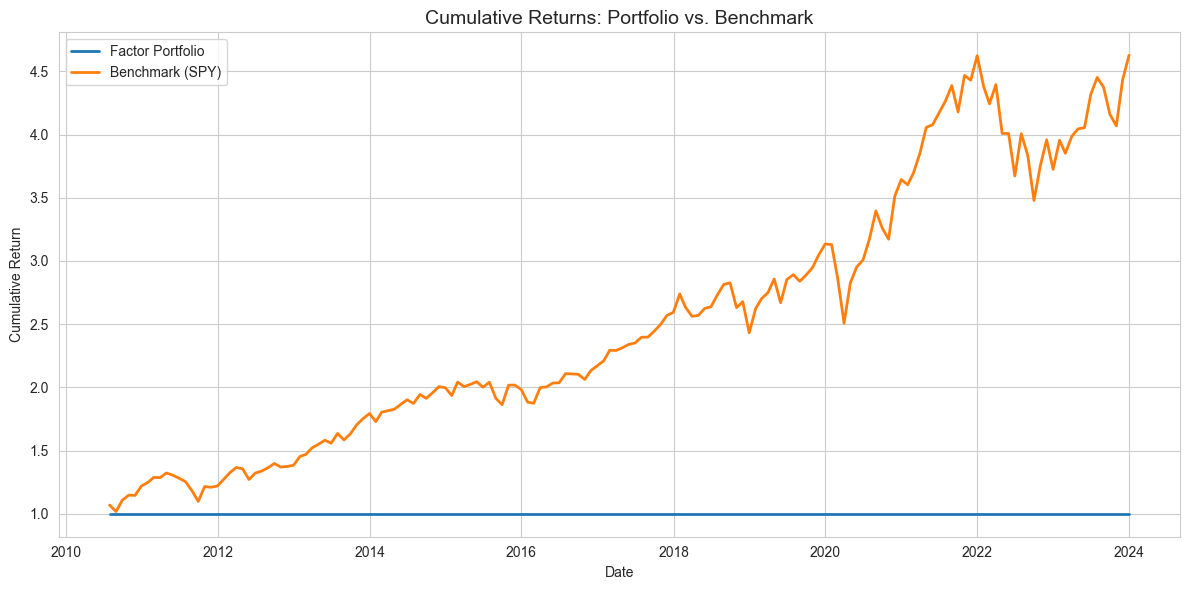

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

def plot_cumulative_returns(performance_df, title='Cumulative Returns: Portfolio vs. Benchmark'):
    cumulative_portfolio = (
        1 + performance_df['Portfolio_Return']
    ).cumprod()

    cumulative_benchmark = (
        1 + performance_df['Benchmark_Return']
    ).cumprod()
    plt.figure(figsize=(12, 6))

    plt.plot(
        cumulative_portfolio.index,
        cumulative_portfolio,
        label='Factor Portfolio',
        linewidth=2
    )
    plt.plot(
        cumulative_benchmark.index,
        cumulative_benchmark,
        label='Benchmark (SPY)',
        linewidth=2
    )
    plt.title(title, fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')

    plt.legend(
        loc='upper left'
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if not performance_results.empty:
    plot_cumulative_returns(performance_results)
else:
    print("Cannot plot cumulative returns: Performance results are empty.")

### 12.2 Rolling Performance Metrics

Visualizes rolling annualized returns and rolling Sharpe Ratios to assess the consistency of performance over time.

Generating rolling performance plots (window_size=24 months)...


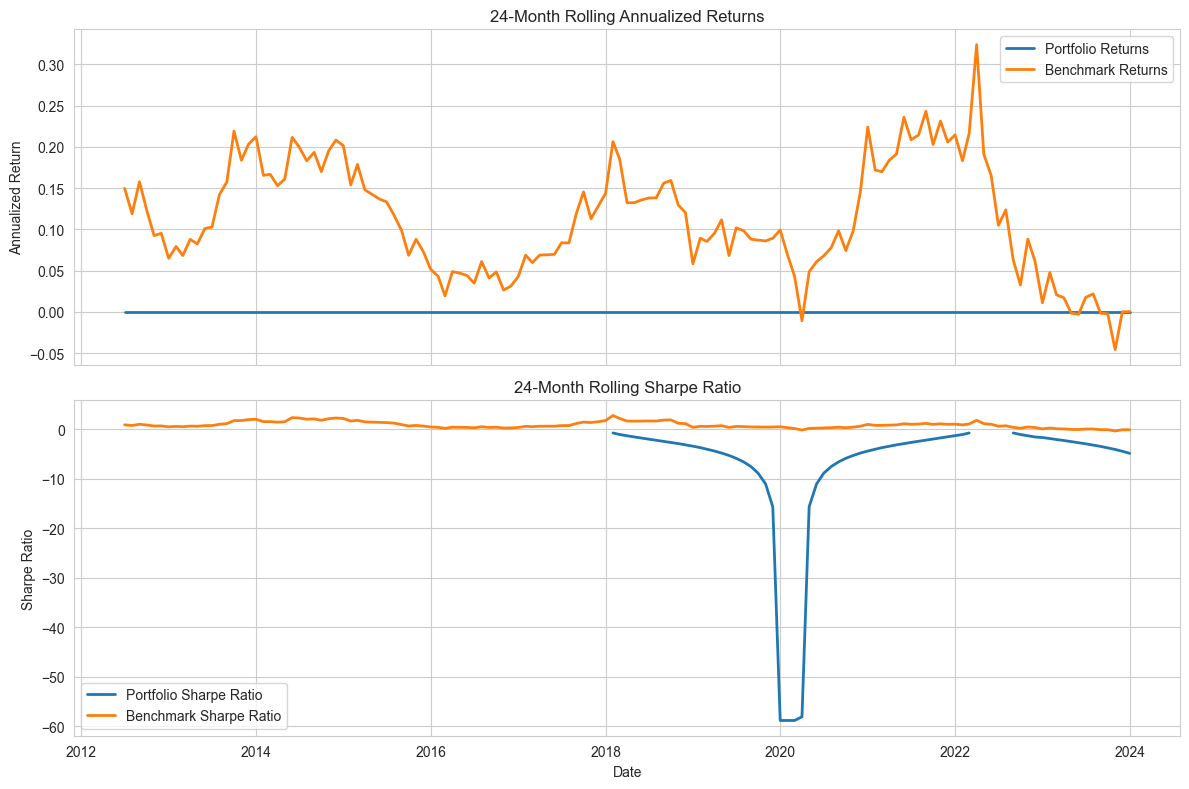

In [106]:
import matplotlib.pyplot as plt
import numpy as np


def plot_rolling_performance(performance_df, window_size=24, annual_factor=12):
    """
    Plots rolling annualized returns and rolling Sharpe Ratios using Matplotlib.

    Args:
        performance_df (pd.DataFrame): DataFrame with portfolio and benchmark returns.
        window_size (int): Rolling window size in months.
        annual_factor (int): Factor to annualize (12 for monthly).
    """

    print(f"Generating rolling performance plots (window_size={window_size} months)...")

    # Rolling annualized returns
    rolling_portfolio_ret = (
        (1 + performance_df['Portfolio_Return'])
        .rolling(window=window_size)
        .apply(lambda x: x.prod()) ** (annual_factor / window_size)
        - 1
    )

    rolling_benchmark_ret = (
        (1 + performance_df['Benchmark_Return'])
        .rolling(window=window_size)
        .apply(lambda x: x.prod()) ** (annual_factor / window_size)
        - 1
    )


    # Rolling Sharpe Ratio
    rolling_portfolio_sharpe = (
        performance_df['Portfolio_Excess_Return']
        .rolling(window=window_size)
        .mean()
        /
        performance_df['Portfolio_Excess_Return']
        .rolling(window=window_size)
        .std()
    ) * np.sqrt(annual_factor)


    rolling_benchmark_sharpe = (
        performance_df['Benchmark_Excess_Return']
        .rolling(window=window_size)
        .mean()
        /
        performance_df['Benchmark_Excess_Return']
        .rolling(window=window_size)
        .std()
    ) * np.sqrt(annual_factor)



    # Create Matplotlib figure
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 8),
        sharex=True
    )


    # ---- Rolling Returns Plot ----
    axes[0].plot(
        rolling_portfolio_ret.index,
        rolling_portfolio_ret,
        label='Portfolio Returns',
        linewidth=2
    )

    axes[0].plot(
        rolling_benchmark_ret.index,
        rolling_benchmark_ret,
        label='Benchmark Returns',
        linewidth=2
    )

    axes[0].set_title(
        f'{window_size}-Month Rolling Annualized Returns'
    )

    axes[0].set_ylabel(
        'Annualized Return'
    )

    axes[0].legend()
    axes[0].grid(True)



    # ---- Rolling Sharpe Plot ----
    axes[1].plot(
        rolling_portfolio_sharpe.index,
        rolling_portfolio_sharpe,
        label='Portfolio Sharpe Ratio',
        linewidth=2
    )

    axes[1].plot(
        rolling_benchmark_sharpe.index,
        rolling_benchmark_sharpe,
        label='Benchmark Sharpe Ratio',
        linewidth=2
    )

    axes[1].set_title(
        f'{window_size}-Month Rolling Sharpe Ratio'
    )

    axes[1].set_ylabel(
        'Sharpe Ratio'
    )

    axes[1].set_xlabel(
        'Date'
    )

    axes[1].legend()
    axes[1].grid(True)


    plt.tight_layout()
    plt.show()



if not performance_results.empty:
    plot_rolling_performance(
        performance_results,
        window_size=24
    )
else:
    print("Cannot plot rolling performance: Performance results are empty.")

### 12.3 Factor Exposures Over Time

Illustrates how the portfolio's exposure to different Fama-French factors changes over the backtesting period. This helps understand the dynamic nature of the factor strategy.

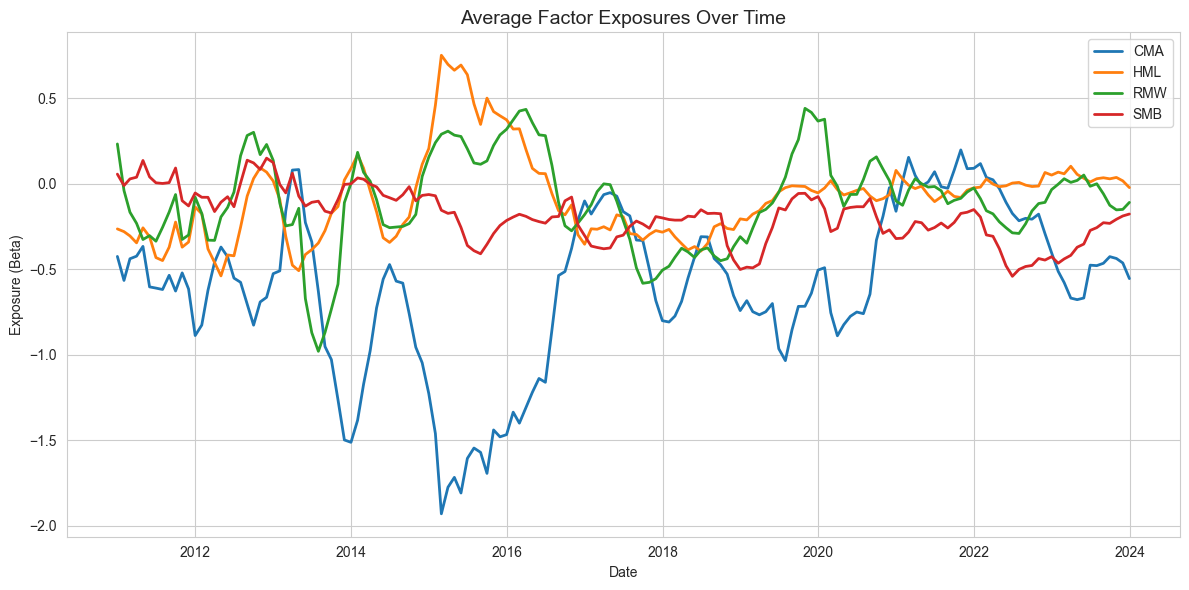

In [108]:
import matplotlib.pyplot as plt

def plot_factor_exposures(factor_exposures_df, ff_factor_names):
    # Reshape factor exposure dataframe
    reshaped_exposures = []

    for col in factor_exposures_df.columns:
        parts = col.rsplit('_', 1)

        if len(parts) == 2:
            ticker, factor = parts

            if factor in ff_factor_names:
                reshaped_exposures.append({
                    'Date': factor_exposures_df.index,
                    'Ticker': ticker,
                    'Factor': factor,
                    'Exposure': factor_exposures_df[col].values
                })
    records = []

    for item in reshaped_exposures:
        for date, exposure in zip(item['Date'], item['Exposure']):
            records.append({
                'Date': date,
                'Ticker': item['Ticker'],
                'Factor': item['Factor'],
                'Exposure': exposure
            })
    df_exposures = pd.DataFrame(records)

    if df_exposures.empty:
        print("No factor exposures to plot.")
        return
    df_exposures['Date'] = pd.to_datetime(df_exposures['Date'])

    df_exposures = df_exposures.set_index('Date')
    # Average exposure by factor
    monthly_avg_factor_exposures = (
        df_exposures
        .groupby(['Date', 'Factor'])['Exposure']
        .mean()
        .unstack()
    )
    monthly_avg_factor_exposures = (
        monthly_avg_factor_exposures
        .resample('ME')
        .mean()
        .dropna(how='all')
    )


    if monthly_avg_factor_exposures.empty:
        print("No monthly average factor exposures to plot.")
        return
    plt.figure(figsize=(12,6))
    
    for factor in monthly_avg_factor_exposures.columns:
        plt.plot(
            monthly_avg_factor_exposures.index,
            monthly_avg_factor_exposures[factor],
            label=factor,
            linewidth=2
        )
    plt.title(
        'Average Factor Exposures Over Time',
        fontsize=14
    )
    plt.xlabel(
        'Date'
    )
    plt.ylabel(
        'Exposure (Beta)'
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if not factor_exposures.empty and ff_factor_names:
    plot_factor_exposures(
        factor_exposures,
        ff_factor_names
    )
else:
    print("Cannot plot factor exposures: Factor exposure data or factor names are empty.")

## 13. Potential Upgrades

This project provides a solid foundation for an institutional factor investing engine. Several enhancements could further improve its robustness, performance, and real-world applicability:

1.  **Expanded Factor Set:** Incorporate additional factors (e.g., Momentum, Quality, Low Volatility) beyond the Fama-French 5-factor model.
2.  **Dynamic Factor Exposure Estimation:** Explore more sophisticated techniques for estimating factor exposures, such as Kalman filters or machine learning models, instead of simple rolling OLS.
3.  **Advanced Portfolio Optimization:**
    *   Implement alternative optimization objectives (e.g., minimum tracking error, risk parity, custom risk/return objectives).
    *   Add more complex constraints (e.g., sector/industry caps, turnover constraints, transaction costs, ESG considerations).
    *   Integrate Black-Litterman model for incorporating investor views.
4.  **Improved Expected Returns and Covariance Estimation:** Utilize advanced methods like Exponentially Weighted Moving Average (EWMA) for covariance, or factor-based models for expected returns and covariance (e.g., Barra-style risk models).
5.  **Alternative Backtesting Methodologies:** Implement full rebalancing backtest (asset-level) and incorporate more realistic trading assumptions (slippage, liquidity).
6.  **Out-of-Sample Validation:** Strictly separate data into in-sample (for model training/parameter tuning) and out-of-sample (for final performance evaluation) periods.
7.  **Robustness Checks:** Perform sensitivity analysis on key parameters (e.g., rolling window size, lookback periods, optimization constraints).
8.  **Data Quality & Error Handling:** Enhance error handling for API calls, data inconsistencies, and missing data imputation.
9.  **Deployment & Monitoring:** Containerize the application (Docker) and deploy it to a cloud platform (GCP, AWS, Azure) for automated execution and performance monitoring.
10. **Interactive Dashboard:** Develop a dedicated interactive dashboard using Streamlit, Dash, or Plotly Dash for real-time portfolio monitoring and drill-down analysis.
11. **Fundamental Data Integration:** Incorporate fundamental financial data (e.g., balance sheet, income statement) to build proprietary factors or improve stock selection.
12. **Machine Learning Integration:** Use ML models for alpha generation, risk prediction, or factor timing.